# Spatial transcriptomics (Visium) assay (F6 demo)

Per-module deep-dive for the **spatial assay** (`src/iscc/data/{assay,batch,visium}.py`,
DESIGN_features §D "spatial" row, milestone **F6**). Starting from a sampled tumour section, it lays
**Visium-like spots** over the grid, aggregates cells into spots, and applies the spatial batch
model — whose **distinctive requirement is that the technical noise is SPATIALLY CORRELATED**.

**The components.**

1. **Spot layout** — hexagonally-packed spots (`spot_pitch`), each capturing ~1–10 cells
   (`spot_radius`). iscc is 2D (a single section, no $z$).
2. **Spot→cell aggregation** — pool the `cell_exp` of the member cells; surface per-spot ground
   truth (`n_cells`, **dominant clone + clone fractions**, member ids).
3. **Lateral mRNA diffusion** — a Gaussian kernel (`diffusion_sigma`) bleeds expression to
   neighbouring spots (the spatial-mixing artifact deconvolution methods fight).
4. **Spatially-correlated capture-efficiency field** — the HEADLINE piece: a smooth positive random
   field over the spot coords (a squared-exponential GP, `field_lengthscale` / `field_sigma`) ×
   a tissue-boundary falloff (`edge_sigma`). It scales the per-spot library, so the realized depth
   has **positive spatial autocorrelation (Moran's I > 0)**.
5. **Shared §B.2 layer** — per-gene batch factor (`sigma_batch`), per-spot library
   (LogNormal `mu_counts`/`sigma_counts`), the pluggable NB/DM count draw, and ambient soup.

The knobs `mu_counts`/`sigma_counts`, `field_lengthscale`/`field_sigma`, and the count
overdispersion are the **M4 `estimate_visium()` targets** (DESIGN_inference §C.2).

In [1]:
%matplotlib inline
import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iscc.data import Visium, VisiumBatch, VisiumBatchHyperParams, morans_i
from iscc.data import estimate_visium_from_assay

np.random.seed(0)
NB_DIR = os.getcwd()
OUT = os.path.join(NB_DIR, "example_out")
# Reuse the shared example pipeline (tumour -> sample) the other demos build.
if not os.path.isdir(os.path.join(OUT, "sample", "cell_data")):
    subprocess.run([sys.executable, os.path.join(NB_DIR, "generate_example.py")], check=True)


## 1. The sampled section (upstream input)

Load the example `cell_data` (output of `isccsample`): the per-cell **expression**, **clone**
labels and spatial **coordinates** — the biology the spatial assay measures.

1448 cells, 6000 genes, grid_side=129, 22 clones


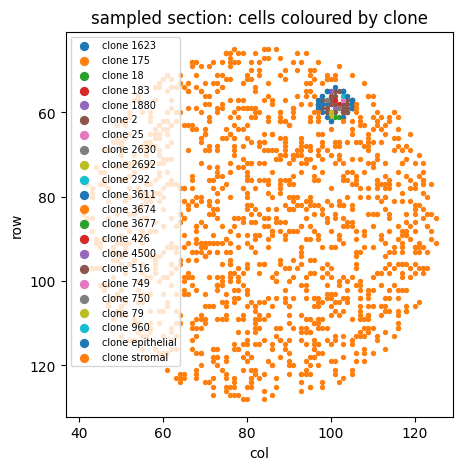

In [2]:
from iscc.data.main import load_cell_data
sample = load_cell_data(os.path.join(OUT, "sample"))
cell_exp = sample["cell_exp"]
cell_crd = sample["cell_crd"]
clone = sample["cell_type"].iloc[:, 0].astype(str)
grid_side = int(cell_crd.max().max()) + 1
print(f"{len(cell_exp)} cells, {cell_exp.shape[1]} genes, grid_side={grid_side}, "
      f"{clone.nunique()} clones")

fig, ax = plt.subplots(figsize=(5, 5))
for cl in sorted(clone.unique()):
    m = clone.values == cl
    ax.scatter(cell_crd["col"].values[m], cell_crd["row"].values[m], s=8, label=f"clone {cl}")
ax.set_title("sampled section: cells coloured by clone"); ax.invert_yaxis()
ax.set_xlabel("col"); ax.set_ylabel("row"); ax.legend(fontsize=7, markerscale=2)
plt.show()

## 2. Run the Visium assay → spot counts + ground truth

One call lays the spots, aggregates cells, draws the spatial capture field, and emits per-spot
counts. The output is an **AnnData** (`X` = spots × genes, `obsm["spatial"]` = coords, `.obs` =
ground truth, `.uns` = hyperparams).

In [3]:
assay = Visium(seed=10, spot_pitch=2.0, spot_radius=1.2, count_model="dm",
               mu_counts=6000.0, sigma_counts=0.3, field_lengthscale=7.0, field_sigma=0.45,
               edge_sigma=0.25).run(sample, grid_side=grid_side)
adata = assay.to_anndata()
print(adata)
print("\nper-spot ground truth (head):")
display = assay.obs[["n_cells", "clone", "clone_frac", "n_counts", "capture_field"]].head()
display

AnnData object with n_obs × n_vars = 4736 × 6000
    obs: 'batch', 'n_cells', 'n_counts', 'library', 'capture_field', 'clone', 'clone_frac', 'row', 'col', 'in_tissue', 'total_counts'
    uns: 'spatial', 'assay', 'protocol', 'count_model', 'batch_seed', 'hyperparams', 'capture_field'
    obsm: 'spatial'

per-spot ground truth (head):


,n_cells,clone,clone_frac,n_counts,capture_field
spot,,,,,
S0,0,,0.0,0,1.083021
S1,0,,0.0,0,0.680818
S2,0,,0.0,0,0.421719
S3,0,,0.0,0,0.292918
S4,0,,0.0,0,0.248631


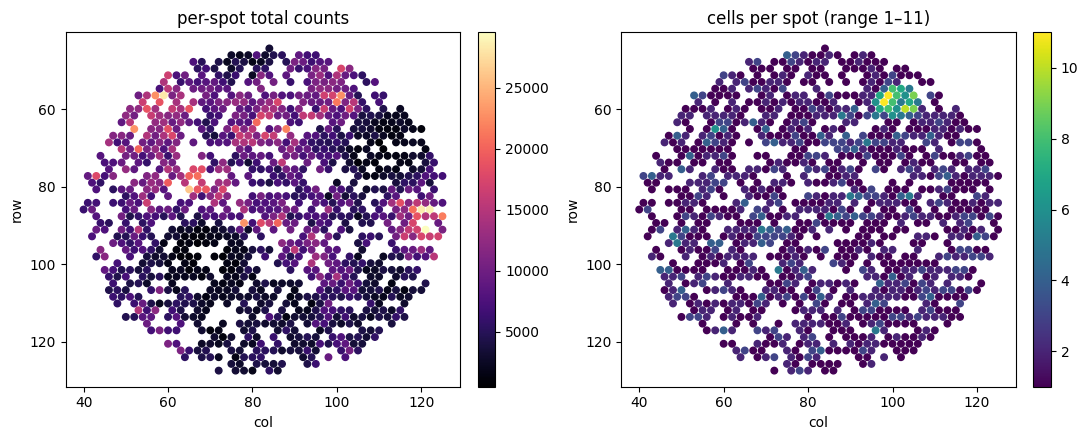

In [4]:
occ = assay.obs.n_cells.values > 0
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = axes[0].scatter(assay.spot_coords[occ, 1], assay.spot_coords[occ, 0],
                      c=assay.obs.n_counts.values[occ], cmap="magma", s=22)
axes[0].set_title("per-spot total counts"); axes[0].invert_yaxis()
fig.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)
sc1 = axes[1].scatter(assay.spot_coords[occ, 1], assay.spot_coords[occ, 0],
                      c=assay.obs.n_cells.values[occ], cmap="viridis", s=22)
axes[1].set_title(f"cells per spot (range {assay.obs.n_cells[occ].min()}"
                  f"–{assay.obs.n_cells[occ].max()})"); axes[1].invert_yaxis()
fig.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)
for ax in axes: ax.set_xlabel("col"); ax.set_ylabel("row")
plt.tight_layout(); plt.show()

## 3. The headline: the spatially-correlated capture field

The capture-efficiency field is a smooth positive random field over the spots. Plot it as a heatmap
and quantify its spatial structure with **Moran's I** (global spatial autocorrelation): a value
$> 0$ means neighbouring spots have *similar* capture efficiency — the spatial technical signature
real Visium carries.

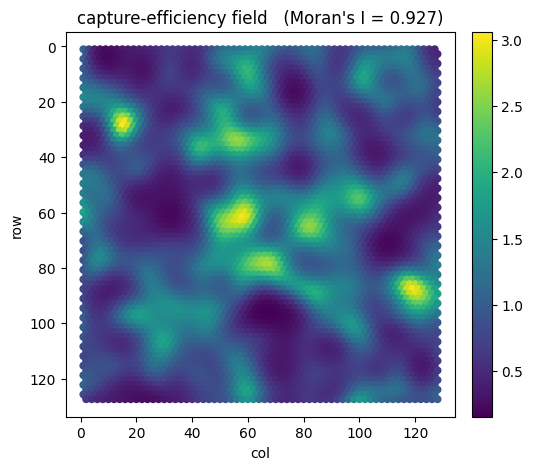

Moran's I of the capture field = 0.927  (>0 -> positive spatial autocorrelation)


In [5]:
mi = morans_i(assay.capture_field, assay.spot_coords)
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(assay.spot_coords[:, 1], assay.spot_coords[:, 0], c=assay.capture_field,
                cmap="viridis", s=22)
ax.set_title(f"capture-efficiency field   (Moran's I = {mi:.3f})"); ax.invert_yaxis()
ax.set_xlabel("col"); ax.set_ylabel("row"); fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
plt.show()
print(f"Moran's I of the capture field = {mi:.3f}  (>0 -> positive spatial autocorrelation)")

**Moran's I rises with `field_lengthscale`.** A longer autocorrelation length makes the field
smoother — larger coherent patches — i.e. *more* spatial autocorrelation. Sweep it on a fixed spot
grid (via `VisiumBatch` directly) and watch Moran's I climb.

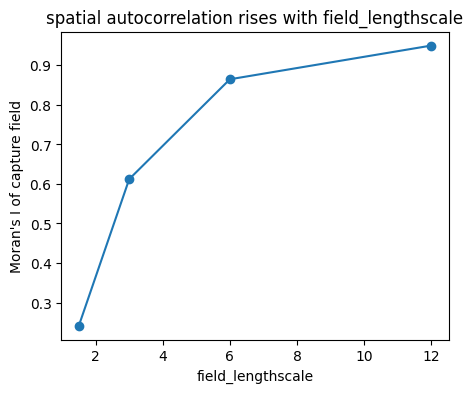

{1.5: 0.242, 3.0: 0.612, 6.0: 0.864, 12.0: 0.95}


In [6]:
coords = assay.spot_coords
genes = list(cell_exp.columns)
base = np.ones(len(genes))
lengthscales = [1.5, 3.0, 6.0, 12.0]
mis = []
for L in lengthscales:
    b = VisiumBatch(VisiumBatchHyperParams(field_lengthscale=L, field_sigma=0.45, edge_sigma=0.0),
                    seed=1).realize(genes, base, coords)
    mis.append(morans_i(b.capture_field, coords))
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(lengthscales, mis, "o-")
ax.set_xlabel("field_lengthscale"); ax.set_ylabel("Moran's I of capture field")
ax.set_title("spatial autocorrelation rises with field_lengthscale")
plt.show()
print(dict(zip(lengthscales, [round(m, 3) for m in mis])))

## 4. Lateral mRNA diffusion

`diffusion_sigma` bleeds each spot's expression into its neighbours (a Gaussian kernel). Increasing
it makes neighbouring spots' expression profiles **more correlated** — the spatial mixing that
deconvolution methods must undo.

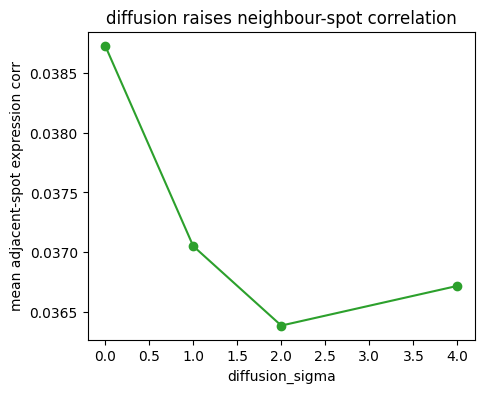

{0.0: 0.039, 1.0: 0.037, 2.0: 0.036, 4.0: 0.037}


In [7]:
def mean_adjacent_corr(diffusion_sigma):
    a = Visium(seed=2, spot_pitch=2.0, spot_radius=1.2, diffusion_sigma=diffusion_sigma,
               ambient_frac=0.0, field_sigma=0.0, edge_sigma=0.0).run(sample, grid_side=grid_side)
    counts = a.spot_counts.values
    comp = counts / np.maximum(counts.sum(1, keepdims=True), 1)
    co = a.spot_coords; corrs = []
    for i in range(len(co)):
        for j in range(i + 1, len(co)):
            d2 = float(((co[i] - co[j]) ** 2).sum())
            if 1.5 < d2 < 5.0 and comp[i].sum() > 0 and comp[j].sum() > 0:
                corrs.append(np.corrcoef(comp[i], comp[j])[0, 1])
    return float(np.nanmean(corrs))

sigmas = [0.0, 1.0, 2.0, 4.0]
corrs = [mean_adjacent_corr(s) for s in sigmas]
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(sigmas, corrs, "o-", color="tab:green")
ax.set_xlabel("diffusion_sigma"); ax.set_ylabel("mean adjacent-spot expression corr")
ax.set_title("diffusion raises neighbour-spot correlation")
plt.show()
print(dict(zip(sigmas, [round(c, 3) for c in corrs])))

## 5. `estimate_visium()` round-trip (M4 §C.2)

The spatial analogue of `estimate()`/`estimate_dna()`: fit the technical hypers back from the
per-spot counts + coords, then check the recovery of the library size and the capture-field
autocorrelation length. The `.fitted` map is honest — `ambient_frac` / `edge_sigma` /
`diffusion_sigma` are carried prior-only (unidentifiable from a single section's counts).

In [8]:
est = estimate_visium_from_assay(assay)
print(est)
print("\nfitted:", est.fitted)
print("recovery:")
for k, true in [("mu_counts", 6000.0), ("sigma_counts", 0.3),
                ("field_sigma", 0.45), ("field_lengthscale", 7.0)]:
    print(f"  {k:16s} true={true:<7.2f} fit={getattr(est.hypers, k):.3f}")

VisiumEstimate(count_model='dm', n_spots=4736, spots_per_tissue=1141, occupied_fraction=0.24, mu_counts=7171, sigma_counts=0.298, field_sigma=0.608, field_lengthscale=8.14, kappa=132.0, sigma_batch=0.100, fitted=['mu_counts', 'sigma_counts', 'field_sigma', 'field_lengthscale', 'kappa'])

fitted: ['mu_counts', 'sigma_counts', 'field_sigma', 'field_lengthscale', 'kappa']
recovery:
  mu_counts        true=6000.00 fit=7171.018
  sigma_counts     true=0.30    fit=0.298
  field_sigma      true=0.45    fit=0.608
  field_lengthscale true=7.00    fit=8.137


**Takeaways.** The Visium assay reuses the shared scRNA batch machinery (per-gene factor,
ambient, pluggable NB/DM count draw) and adds the spatial-specific layer: spot aggregation, lateral
diffusion, and the **spatially-autocorrelated capture field** (Moran's I $> 0$, rising with
`field_lengthscale`). `estimate_visium()` inverts the library + field structure from per-spot counts
+ coordinates; `validation/validate_visium.py` shows the full fit → re-simulate → overlay round-trip.
Mutation-aware **spot-barcoded reads** (the clone-mixture RNA-VAF) are in
`iscc.data.reads.emit_visium_reads` (reuses F7b).